# Results Analysis — HGT vs HAN (RC element dimension prediction)

Analyzes everything logged in `results/hgt/` and `results/han/` to answer three questions:

1. **Which model + PE/isolated combination is best?** (internal 15% split *and* the external held-out `data/test`)
2. **Is there a problem with the DATA itself?** — using per-node true/pred labels across both models to separate *data noise* from *model error*.
3. **Full breakdown** — per type (beam/column), per dimension (width b / height h), connected vs isolated, error-vs-size, statistical significance.

Everything is read-only from `results/`. New artifacts are written to `results/analysis/`.
Baselines: a naive per-type train-median predictor (logged as `baseline_MAE`). Both models must beat it.

In [1]:
# --- Cell 1: setup ---
import os, json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")
try:
    from scipy.stats import wilcoxon
    HAVE_SCIPY = True
except Exception:
    HAVE_SCIPY = False

pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:.3f}".format)
sns.set_context("notebook"); plt.rcParams["figure.dpi"] = 110

# resolve results dir whether run from repo root or notebooks/
ROOT = ".." if os.path.basename(os.getcwd()) == "notebooks" else "."
RES = os.path.join(ROOT, "results")
MODELS = ["hgt", "han"]
OUT = os.path.join(RES, "analysis"); os.makedirs(OUT, exist_ok=True)
FIG = os.path.join(OUT, "figures"); os.makedirs(FIG, exist_ok=True)
HIT_TOL = 5.0  # cm; the "within tolerance" hit-rate threshold used in the sweep

def rp(model, fname): return os.path.join(RES, model, fname)
def load_csv(model, fname):
    p = rp(model, fname)
    return pd.read_csv(p) if os.path.exists(p) else None
def load_json(model, fname):
    p = rp(model, fname)
    return json.load(open(p)) if os.path.exists(p) else None

print("results dir:", os.path.abspath(RES))
for m in MODELS:
    print(f"  {m}: exists={os.path.isdir(os.path.join(RES,m))}")
print("outputs ->", os.path.abspath(OUT))

results dir: /Users/sarayetel/Desktop/Research/Graph/RC-Element-Prediction-GNN/results
  hgt: exists=True
  han: exists=True
outputs -> /Users/sarayetel/Desktop/Research/Graph/RC-Element-Prediction-GNN/results/analysis


## 1. Model × combination — internal 15% split sweep

`pe_isolated_sweep.csv` has 9 combos (PE ∈ {topological, geometric, hybrid} × isolated ∈ {none, self_loop, knn}) per model.
We stack both models into one long table and rank by **weighted MAE** (node-pooled, the headline metric).

In [2]:
# --- Cell 2: combined sweep table ---
frames = []
for m in MODELS:
    df = load_csv(m, "pe_isolated_sweep.csv")
    if df is None:
        print(f"!! no sweep for {m}"); continue
    df = df.copy(); df.insert(0, "model", m.upper())
    df["combo"] = df["PE"] + "_" + df["isolated"]
    frames.append(df)
sweep = pd.concat(frames, ignore_index=True)
sweep.to_csv(os.path.join(OUT, "combined_sweep.csv"), index=False)

key = ["model","PE","isolated","weighted_MAE","unweighted_MAE","beam_MAE","col_MAE",
       "width_MAE","height_MAE","pct_within_tol","overall_R2","improve_vs_baseline",
       "cv_MAE","cv_MAE_std"]
key = [c for c in key if c in sweep.columns]
ranked = sweep.sort_values("weighted_MAE").reset_index(drop=True)
print("ALL 18 (model × combo), ranked by internal weighted MAE (cm):")
print(ranked[key].to_string(index=False))

print("\nBest combo per model (internal split):")
for m in MODELS:
    s = sweep[sweep.model==m.upper()].sort_values("weighted_MAE")
    if len(s):
        b = s.iloc[0]
        print(f"  {m.upper():4s}: {b['PE']:11s} / {b['isolated']:9s} -> "
              f"weighted {b['weighted_MAE']:.3f} | hit% {b['pct_within_tol']:.1f} | R2 {b['overall_R2']:.3f}")
ranked[key]

ALL 18 (model × combo), ranked by internal weighted MAE (cm):
model          PE  isolated  weighted_MAE  unweighted_MAE  beam_MAE  col_MAE  width_MAE  height_MAE  pct_within_tol  overall_R2  improve_vs_baseline  cv_MAE  cv_MAE_std
  HAN topological      none         5.512           5.633     5.291    5.975      6.517       4.506          63.900       0.552                2.814   4.635       0.230
  HAN topological self_loop         5.566           5.666     5.385    5.947      6.673       4.460          63.100       0.555                2.759   4.619       0.174
  HAN   geometric      none         5.590           5.731     5.334    6.128      6.609       4.571          61.900       0.548                2.735   4.664       0.243
  HGT      hybrid self_loop         5.710           5.816     5.515    6.117      6.869       4.550          59.100       0.542                2.616     NaN         NaN
  HGT topological       knn         5.719           5.834     5.511    6.157      6.995      

,model,PE,isolated,weighted_MAE,unweighted_MAE,beam_MAE,col_MAE,width_MAE,height_MAE,pct_within_tol,overall_R2,improve_vs_baseline,cv_MAE,cv_MAE_std
0,HAN,topological,none,5.512,5.633,5.291,5.975,6.517,4.506,63.900,0.552,2.814,4.635,0.230
1,HAN,topological,self_loop,5.566,5.666,5.385,5.947,6.673,4.460,63.100,0.555,2.759,4.619,0.174
2,HAN,geometric,none,5.590,5.731,5.334,6.128,6.609,4.571,61.900,0.548,2.735,4.664,0.243
3,HGT,hybrid,self_loop,5.710,5.816,5.515,6.117,6.869,4.550,59.100,0.542,2.616,NaN,NaN
4,HGT,topological,knn,5.719,5.834,5.511,6.157,6.995,4.443,59.600,0.548,2.606,NaN,NaN
5,HAN,geometric,knn,5.721,5.849,5.487,6.210,6.861,4.580,61.000,0.522,2.605,4.607,0.188
6,HGT,geometric,self_loop,5.739,5.846,5.543,6.148,6.948,4.529,58.300,0.545,2.587,NaN,NaN
7,HGT,geometric,knn,5.743,5.840,5.566,6.114,7.048,4.438,59.100,0.537,2.583,NaN,NaN
8,HAN,geometric,self_loop,5.766,5.910,5.505,6.315,6.886,4.647,61.300,0.521,2.560,4.706,0.216
9,HGT,topological,none,5.816,5.925,5.618,6.231,6.935,4.696,58.400,0.530,2.510,NaN,NaN


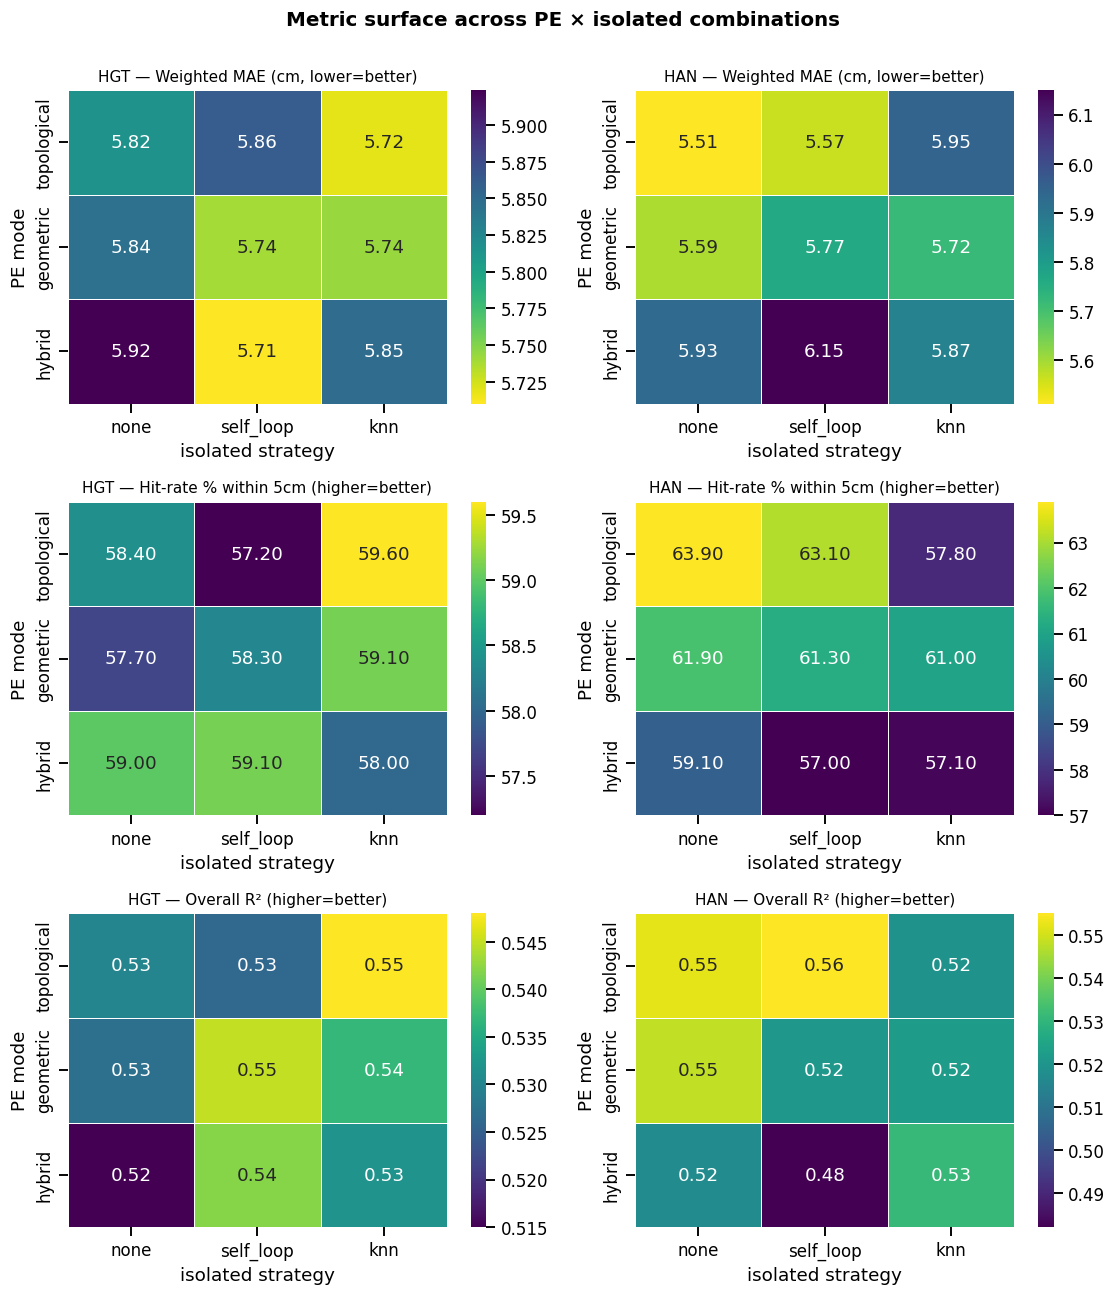

In [3]:
# --- Cell 3: heatmaps of weighted MAE across PE × isolated, per model ---
PE_ORDER = ["topological","geometric","hybrid"]; ISO_ORDER = ["none","self_loop","knn"]
metrics_to_map = [("weighted_MAE","Weighted MAE (cm, lower=better)","viridis_r"),
                  ("pct_within_tol","Hit-rate % within 5cm (higher=better)","viridis"),
                  ("overall_R2","Overall R² (higher=better)","viridis")]
fig, axes = plt.subplots(len(metrics_to_map), len(MODELS),
                         figsize=(5.2*len(MODELS), 4.0*len(metrics_to_map)), squeeze=False)
for r,(metric,title,cmap) in enumerate(metrics_to_map):
    for c,m in enumerate(MODELS):
        ax = axes[r][c]; s = sweep[sweep.model==m.upper()]
        piv = s.pivot(index="PE", columns="isolated", values=metric).reindex(index=PE_ORDER, columns=ISO_ORDER)
        sns.heatmap(piv, annot=True, fmt=".2f", cmap=cmap, ax=ax, cbar=True,
                    linewidths=.5, linecolor="white")
        ax.set_title(f"{m.upper()} — {title}", fontsize=10)
        ax.set_xlabel("isolated strategy"); ax.set_ylabel("PE mode")
fig.suptitle("Metric surface across PE × isolated combinations", fontsize=13, fontweight="bold")
fig.tight_layout(rect=[0,0,1,0.98]); fig.savefig(os.path.join(FIG,"sweep_heatmaps.png"), bbox_inches="tight")
plt.show()

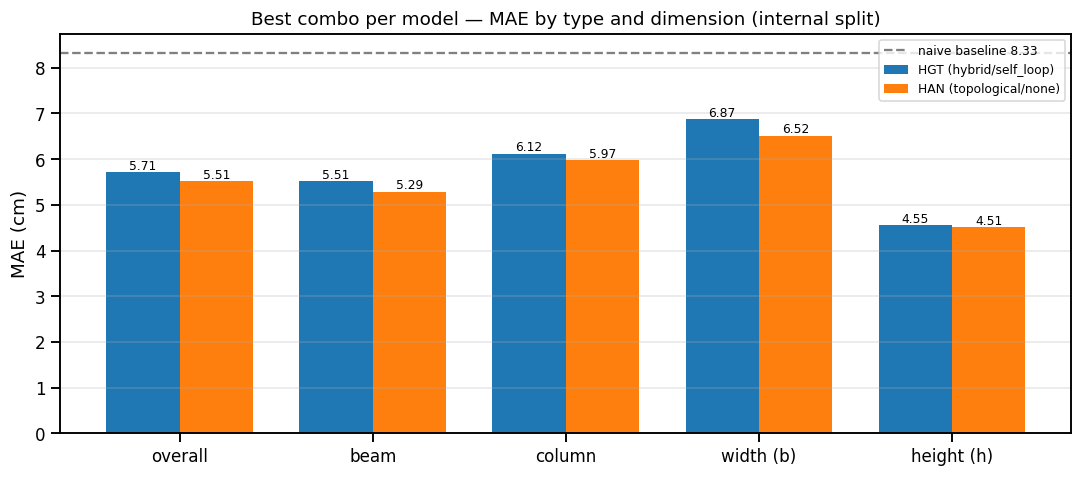

In [4]:
# --- Cell 4: best-combo head-to-head (internal) across type & dimension ---
best = {}
for m in MODELS:
    s = sweep[sweep.model==m.upper()].sort_values("weighted_MAE")
    if len(s): best[m] = s.iloc[0]

metrics = ["weighted_MAE","beam_MAE","col_MAE","width_MAE","height_MAE"]
labels  = ["overall","beam","column","width (b)","height (h)"]
x = np.arange(len(metrics)); w = 0.38
fig, ax = plt.subplots(figsize=(10,4.5))
for i,m in enumerate(MODELS):
    if m not in best: continue
    vals = [best[m].get(k, np.nan) for k in metrics]
    bars = ax.bar(x + (i-0.5)*w, vals, w, label=f"{m.upper()} ({best[m]['PE']}/{best[m]['isolated']})")
    for b,v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)
# baseline line (weighted)
bl = sweep["baseline_MAE"].dropna().iloc[0] if "baseline_MAE" in sweep else np.nan
if np.isfinite(bl): ax.axhline(bl, ls="--", color="gray", label=f"naive baseline {bl:.2f}")
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel("MAE (cm)")
ax.set_title("Best combo per model — MAE by type and dimension (internal split)")
ax.legend(fontsize=8); ax.grid(alpha=.3, axis="y")
fig.tight_layout(); fig.savefig(os.path.join(FIG,"best_combo_headtohead.png"), bbox_inches="tight"); plt.show()

## 2. External held-out test (`data/test`) — the honest numbers

The sweep's "internal" numbers come from a 15% split of the training pool. `test_metrics.json` is the model
**deployed** (retrained on all train graphs, its winning combo) evaluated on the fully separate `data/test`.
This is the number to report.

EXTERNAL TEST (real cm):
       weighted_MAE  unweighted_MAE  beam_MAE  col_MAE  width_MAE  height_MAE  overall_R2  beam_R2  col_R2  baseline_MAE  improve_vs_baseline
model                                                                                                                                        
HGT           4.930           4.627     5.461    3.793      5.239       4.622       0.584    0.534   0.458         7.344                2.414
HAN           5.037           4.730     5.573    3.888      5.359       4.715       0.588    0.536   0.477         7.344                2.307
  HGT deployed combo: hybrid/self_loop
  HAN deployed combo: topological/none


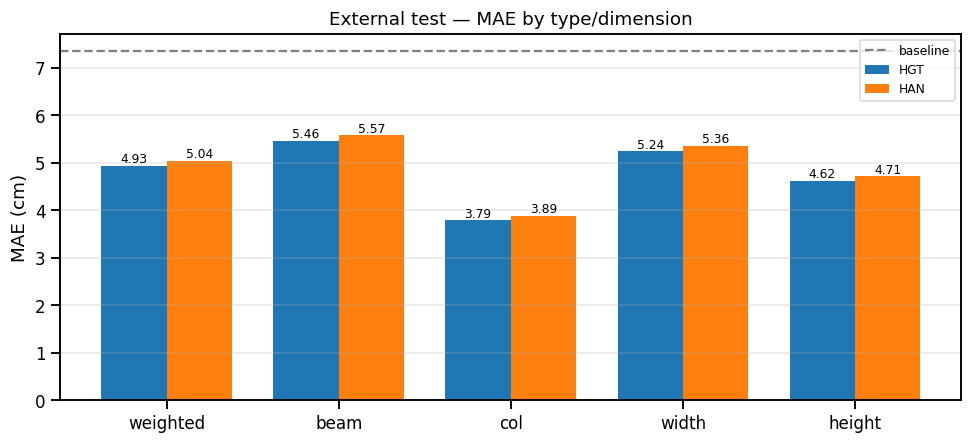

In [5]:
# --- Cell 5: external test comparison ---
rows = []
for m in MODELS:
    j = load_json(m, "test_metrics.json")
    if j: rows.append({"model": m.upper(), **j})
ext = pd.DataFrame(rows).set_index("model")
ext.to_csv(os.path.join(OUT, "combined_external_test.csv"))
show = [c for c in ["weighted_MAE","unweighted_MAE","beam_MAE","col_MAE","width_MAE","height_MAE",
                    "overall_R2","beam_R2","col_R2","baseline_MAE","improve_vs_baseline"] if c in ext.columns]
print("EXTERNAL TEST (real cm):"); print(ext[show].to_string())

# which deployed combo each used (from best_model_summary)
for m in MODELS:
    bj = load_json(m, "best_model_summary.json")
    if bj and "best" in bj:
        b = bj["best"]; print(f"  {m.upper()} deployed combo: {b.get('PE')}/{b.get('isolated')}")

fig, ax = plt.subplots(figsize=(9,4.2))
mets = [c for c in ["weighted_MAE","beam_MAE","col_MAE","width_MAE","height_MAE"] if c in ext.columns]
x=np.arange(len(mets)); w=.38
for i,m in enumerate(ext.index):
    vals=[ext.loc[m,k] for k in mets]
    bars=ax.bar(x+(i-.5)*w, vals, w, label=m)
    for b,v in zip(bars,vals): ax.text(b.get_x()+b.get_width()/2,v,f"{v:.2f}",ha="center",va="bottom",fontsize=8)
if "baseline_MAE" in ext.columns: ax.axhline(ext["baseline_MAE"].iloc[0], ls="--", color="gray", label="baseline")
ax.set_xticks(x); ax.set_xticklabels([m.replace("_MAE","") for m in mets]); ax.set_ylabel("MAE (cm)")
ax.set_title("External test — MAE by type/dimension"); ax.legend(fontsize=8); ax.grid(alpha=.3,axis="y")
fig.tight_layout(); fig.savefig(os.path.join(FIG,"external_test_headtohead.png"), bbox_inches="tight"); plt.show()

## 3. Is the HGT–HAN difference real? — paired statistics on identical nodes

Two paired tests on per-node MAE (same nodes evaluated by both models):
- **Architecture A/B (fair):** both models on the *same* combo (labels are identical, verified), isolating the operator (HGTConv vs HANConv).
- **Deployment A/B:** each model's *own* deployed combo on the external test set.

Wilcoxon signed-rank (non-parametric, paired) + mean paired difference + % of nodes where HAN < HGT.

In [6]:
# --- Cell 6: paired architecture comparison on a common combo ---
def paired_compare(h, a, keys, title):
    m = h.merge(a, on=keys, suffixes=("_hgt","_han"))
    d = m["node_mae_han"] - m["node_mae_hgt"]   # negative => HAN better
    res = {"n": len(m),
           "HGT_mae": m["node_mae_hgt"].mean(), "HAN_mae": m["node_mae_han"].mean(),
           "mean_diff(HAN-HGT)": d.mean(), "median_diff": d.median(),
           "HAN_better_%": 100*(d<0).mean()}
    if HAVE_SCIPY and len(m)>10 and d.abs().sum()>0:
        try: res["wilcoxon_p"] = wilcoxon(m["node_mae_hgt"], m["node_mae_han"]).pvalue
        except Exception as e: res["wilcoxon_p"]=np.nan
    print(f"\n[{title}]  n={res['n']}")
    print(f"  HGT MAE {res['HGT_mae']:.3f} | HAN MAE {res['HAN_mae']:.3f} cm")
    print(f"  mean diff (HAN-HGT) = {res['mean_diff(HAN-HGT)']:+.3f} cm  (<0 => HAN better)")
    print(f"  HAN better on {res['HAN_better_%']:.1f}% of nodes"
          + (f" | Wilcoxon p={res.get('wilcoxon_p',float('nan')):.2e}" if 'wilcoxon_p' in res else ""))
    return res

hpn = load_csv("hgt","pe_isolated_pernode_errors.csv")
apn = load_csv("han","pe_isolated_pernode_errors.csv")
KEYS = ["combo","sample","node_type","node_idx"]
ab_rows=[]
# same-combo architecture A/B for every combo
for c in sorted(set(hpn["combo"]) & set(apn["combo"])):
    r = paired_compare(hpn[hpn.combo==c], apn[apn.combo==c], KEYS, f"same-combo A/B: {c}")
    r["combo"]=c; ab_rows.append(r)
ab = pd.DataFrame(ab_rows); ab.to_csv(os.path.join(OUT,"architecture_ab_by_combo.csv"), index=False)

# deployment A/B on external test
th = load_csv("hgt","test_pernode_errors.csv"); ta = load_csv("han","test_pernode_errors.csv")
paired_compare(th, ta, ["sample","node_type","node_idx"], "deployment A/B (external test)")
print("\nsaved architecture_ab_by_combo.csv")


[same-combo A/B: geometric_knn]  n=8281
  HGT MAE 5.743 | HAN MAE 5.721 cm
  mean diff (HAN-HGT) = -0.022 cm  (<0 => HAN better)
  HAN better on 46.1% of nodes | Wilcoxon p=4.02e-05

[same-combo A/B: geometric_none]  n=8281
  HGT MAE 5.845 | HAN MAE 5.590 cm
  mean diff (HAN-HGT) = -0.255 cm  (<0 => HAN better)
  HAN better on 56.5% of nodes | Wilcoxon p=1.86e-35

[same-combo A/B: geometric_self_loop]  n=8281
  HGT MAE 5.739 | HAN MAE 5.766 cm
  mean diff (HAN-HGT) = +0.027 cm  (<0 => HAN better)
  HAN better on 50.7% of nodes | Wilcoxon p=4.65e-01

[same-combo A/B: hybrid_knn]  n=8281
  HGT MAE 5.849 | HAN MAE 5.868 cm
  mean diff (HAN-HGT) = +0.019 cm  (<0 => HAN better)
  HAN better on 50.1% of nodes | Wilcoxon p=3.21e-01

[same-combo A/B: hybrid_none]  n=8281
  HGT MAE 5.924 | HAN MAE 5.933 cm
  mean diff (HAN-HGT) = +0.009 cm  (<0 => HAN better)
  HAN better on 46.3% of nodes | Wilcoxon p=2.05e-01

[same-combo A/B: hybrid_self_loop]  n=8281
  HGT MAE 5.710 | HAN MAE 6.150 cm
  me

## 4. Data-quality forensics — is the problem the data or the model?

Core idea: **errors that BOTH independent models make on the same node/sample are unlikely to be model-specific**
— they point at label noise, feature problems, or genuinely hard/ambiguous cases. We use the per-node true labels
(identical across models) to look for:
- implausible / out-of-range labels (structural elements should not be ~5 cm),
- samples where *both* models fail badly (data-suspect graphs),
- nodes where *both* models are far off with the *same* sign (mislabel suspects),
- isolated vs connected performance, and error-vs-size structure (bias / heteroscedasticity).

unique physical nodes (combo topological_none): 8281  (beam 5609, column 2672)

label summary by type (cm):
node_type        beam   column
true_b count 5609.000 2672.000
       mean    50.182   56.467
       std     12.175   15.969
       min      5.000   25.000
       25%     45.000   50.000
       50%     50.000   50.000
       75%     60.000   60.000
       max    100.000  100.000
true_h count 5609.000 2672.000
       mean    43.734   53.174
       std     10.960    7.385
       min      5.000   30.000
       25%     40.000   50.000
       50%     50.000   50.000
       75%     50.000   60.000
       max     70.000   70.000

[flag] elements with a dimension < 15 cm: 46 (0.6%)
  by type: {'beam': 46, 'column': 0}
[flag] beams with width>height (b>h): 3153 of 5609

top-10 most frequent (b,h) label pairs:
bh
(50.0, 50.0)     1997
(60.0, 50.0)      739
(45.0, 45.0)      511
(50.0, 40.0)      477
(60.0, 60.0)      352
(40.0, 30.0)      289
(100.0, 60.0)     253
(40.0, 40.0)      246
(70.

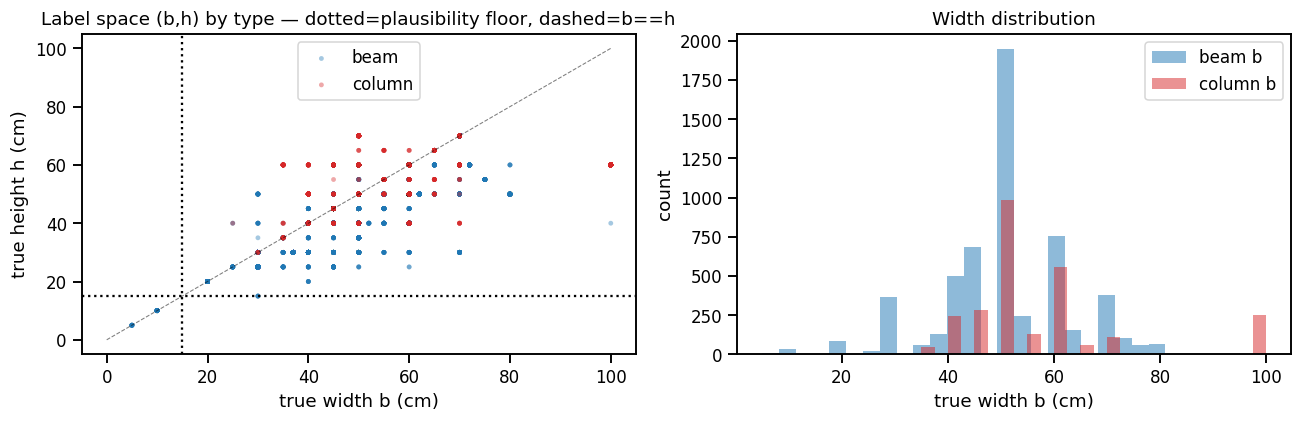

In [7]:
# --- Cell 7: label distribution & plausibility (labels identical across models -> use HGT pernode) ---
# de-duplicate to unique (sample,node) using ONE combo so each physical node counts once
one_combo = hpn["combo"].value_counts().index[0]
lab = hpn[hpn.combo==one_combo][["sample","node_type","node_idx","true_b","true_h"]].copy()
print(f"unique physical nodes (combo {one_combo}): {len(lab)}  "
      f"(beam {sum(lab.node_type=='beam')}, column {sum(lab.node_type=='column')})")
print("\nlabel summary by type (cm):")
print(lab.groupby("node_type")[["true_b","true_h"]].describe().T.to_string())

# plausibility flags
MIN_PLAUSIBLE = 15.0   # cm — RC members below this are physically unusual
lab["b_le_h"]   = lab["true_b"] <= lab["true_h"]
lab["tiny"]     = (lab["true_b"] < MIN_PLAUSIBLE) | (lab["true_h"] < MIN_PLAUSIBLE)
lab["b_gt_h"]   = lab["true_b"] > lab["true_h"]     # width > height (unusual for beams)
print(f"\n[flag] elements with a dimension < {MIN_PLAUSIBLE:.0f} cm: "
      f"{lab['tiny'].sum()} ({100*lab['tiny'].mean():.1f}%)")
print("  by type:", lab.groupby('node_type')['tiny'].sum().to_dict())
print(f"[flag] beams with width>height (b>h): "
      f"{lab[(lab.node_type=='beam')].b_gt_h.sum()} of {sum(lab.node_type=='beam')}")
# most common exact (b,h) pairs — are labels snapping to a few standard sizes?
lab["bh"] = list(zip(lab.true_b, lab.true_h))
print("\ntop-10 most frequent (b,h) label pairs:")
print(lab["bh"].value_counts().head(10).to_string())
lab.drop(columns=["bh"]).to_csv(os.path.join(OUT,"node_labels_flagged.csv"), index=False)

fig, ax = plt.subplots(1,2, figsize=(12,4))
for t,c in [("beam","#1f77b4"),("column","#d62728")]:
    s=lab[lab.node_type==t]
    ax[0].scatter(s.true_b, s.true_h, s=10, alpha=.4, color=c, label=t, edgecolors="none")
ax[0].axvline(MIN_PLAUSIBLE, ls=":", color="k"); ax[0].axhline(MIN_PLAUSIBLE, ls=":", color="k")
ax[0].plot([0,100],[0,100],"k--",lw=.7,alpha=.5)
ax[0].set_xlabel("true width b (cm)"); ax[0].set_ylabel("true height h (cm)")
ax[0].set_title("Label space (b,h) by type — dotted=plausibility floor, dashed=b==h"); ax[0].legend()
for t,c in [("beam","#1f77b4"),("column","#d62728")]:
    s=lab[lab.node_type==t]
    ax[1].hist(s.true_b, bins=30, alpha=.5, color=c, label=f"{t} b")
ax[1].set_xlabel("true width b (cm)"); ax[1].set_ylabel("count"); ax[1].set_title("Width distribution"); ax[1].legend()
fig.tight_layout(); fig.savefig(os.path.join(FIG,"label_distribution.png"), bbox_inches="tight"); plt.show()

Per-sample MAE (mean across 9 combos). 'Both fail' threshold (90th pct of min): 7.31 cm

WORST 12 graphs by mean MAE across both models:
              HGT    HAN  mean_both  min_both
sample                                       
sample_240 12.686 13.381     13.034    12.686
sample_151  8.345  8.231      8.288     8.231
sample_233  7.909  8.017      7.963     7.909
sample_189  7.444  7.402      7.423     7.402
sample_208  7.485  7.293      7.389     7.293
sample_10   6.959  7.202      7.080     6.959
sample_195  6.615  6.562      6.588     6.562
sample_243  6.749  6.352      6.550     6.352
sample_73   6.366  5.662      6.014     5.662
sample_111  6.017  5.579      5.798     5.579
sample_182  5.701  5.658      5.679     5.658
sample_6    5.683  5.544      5.614     5.544

DATA-SUSPECT graphs (BOTH models >= 7.31 cm) — inspect these first: 4
['sample_240', 'sample_151', 'sample_233', 'sample_189']


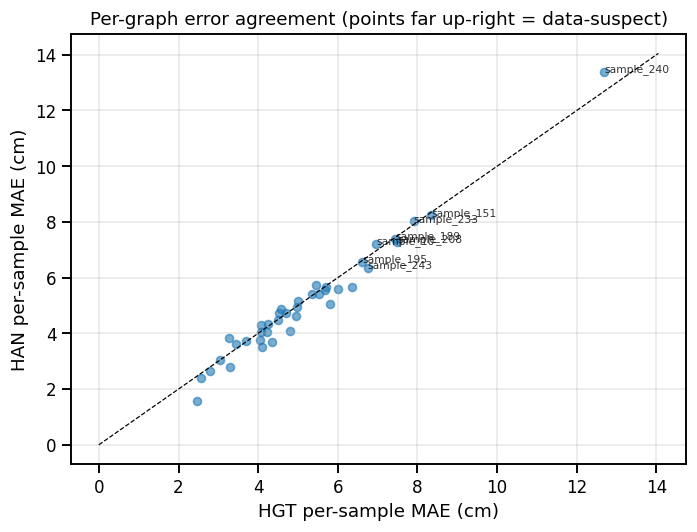

In [8]:
# --- Cell 8: samples where BOTH models fail (data-suspect graphs) ---
# average per-sample MAE across all combos for each model, then intersect the worst.
def sample_mae(model):
    ps = load_csv(model, "pe_isolated_persample_errors.csv")
    return ps.groupby("sample")["MAE"].mean().rename(model.upper())
sm = pd.concat([sample_mae(m) for m in MODELS], axis=1)
sm["mean_both"] = sm.mean(axis=1)
sm["min_both"]  = sm.min(axis=1)
sm = sm.sort_values("mean_both", ascending=False)
sm.to_csv(os.path.join(OUT,"sample_mae_both_models.csv"))
# a graph is "data-suspect" if BOTH models do poorly (min across models still high)
thr = sm["min_both"].quantile(0.90)
suspect = sm[sm["min_both"] >= thr]
print(f"Per-sample MAE (mean across 9 combos). 'Both fail' threshold (90th pct of min): {thr:.2f} cm")
print(f"\nWORST 12 graphs by mean MAE across both models:")
print(sm.head(12).to_string())
print(f"\nDATA-SUSPECT graphs (BOTH models >= {thr:.2f} cm) — inspect these first: {len(suspect)}")
print(suspect.index.tolist())
suspect.to_csv(os.path.join(OUT,"suspect_samples.csv"))

fig, ax = plt.subplots(figsize=(6.5,5))
ax.scatter(sm["HGT"], sm["HAN"], s=28, alpha=.6)
lim=[0, sm[["HGT","HAN"]].max().max()*1.05]; ax.plot(lim,lim,"k--",lw=.8)
for s,row in sm.head(8).iterrows():
    ax.annotate(str(s)[:14], (row["HGT"],row["HAN"]), fontsize=7, alpha=.8)
ax.set_xlabel("HGT per-sample MAE (cm)"); ax.set_ylabel("HAN per-sample MAE (cm)")
ax.set_title("Per-graph error agreement (points far up-right = data-suspect)"); ax.grid(alpha=.3)
fig.tight_layout(); fig.savefig(os.path.join(FIG,"sample_error_agreement.png"), bbox_inches="tight"); plt.show()

In [9]:
# --- Cell 9: nodes where BOTH models are far off with the SAME sign, split by cause ---
# Both models are independent (different operator). When BOTH miss the same node by a lot
# in the same direction, it is NOT a model quirk. Two distinct causes, which need OPPOSITE fixes:
#   (A) LABEL-SUSPECT   : true size is implausibly small (< 20 cm) yet both models predict a
#                          normal ~40-55 cm element -> the LABEL is almost certainly wrong.
#   (B) UNDERFIT/HARD   : true size is normal/large but both models predict smaller (toward the
#                          ~50 cm mode) -> regression-to-mean; a MODEL/feature limitation, not bad data.
combo = "topological_none" if "topological_none" in set(hpn.combo) else sorted(set(hpn.combo))[0]
h1 = hpn[hpn.combo==combo].copy(); a1 = apn[apn.combo==combo].copy()
mm = h1.merge(a1, on=["sample","node_type","node_idx"], suffixes=("_h","_a"))
mm["resid_h"] = ((mm.pred_b_h-mm.true_b_h)+(mm.pred_h_h-mm.true_h_h))/2   # + => model predicts bigger
mm["resid_a"] = ((mm.pred_b_a-mm.true_b_a)+(mm.pred_h_a-mm.true_h_a))/2
mm["both_mae"] = (mm.node_mae_h + mm.node_mae_a)/2
mm["true_size"] = (mm.true_b_h + mm.true_h_h)/2
mm["same_sign"] = np.sign(mm.resid_h)==np.sign(mm.resid_a)
BIG, TINY = 10.0, 20.0
susp = mm[(mm.node_mae_h>BIG)&(mm.node_mae_a>BIG)&(mm.same_sign)].copy()
susp["cause"] = np.where((susp.true_size < TINY) & (susp.resid_h > 0),
                         "A_label_suspect(impossible-small)", "B_underfit(regression-to-mean)")
susp = susp.sort_values("both_mae", ascending=False)
cols = ["sample","node_type","node_idx","true_size","true_b_h","true_h_h",
        "pred_b_h","pred_h_h","pred_b_a","pred_h_a","resid_h","resid_a","both_mae","cause"]
susp[cols].rename(columns={"true_b_h":"true_b","true_h_h":"true_h","pred_b_h":"pred_b_HGT",
    "pred_h_h":"pred_h_HGT","pred_b_a":"pred_b_HAN","pred_h_a":"pred_h_HAN",
    "resid_h":"resid_HGT","resid_a":"resid_HAN"}).to_csv(os.path.join(OUT,"suspect_nodes.csv"), index=False)

nA = (susp.cause.str.startswith("A")).sum(); nB = (susp.cause.str.startswith("B")).sum()
print(f"combo used: {combo}  | nodes where BOTH models err > {BIG} cm, same direction: "
      f"{len(susp)} of {len(mm)} ({100*len(susp)/len(mm):.1f}%)")
print(f"  (A) LABEL-SUSPECT (true<{TINY:.0f}cm but predicted normal) : {nA}"
      f"  -> FIX THE DATA (drop/relabel)")
print(f"  (B) UNDERFIT / regression-to-mean (large true, under-pred): {nB}"
      f"  -> model/feature limitation, not bad data")
print(f"\n(A) worst LABEL-SUSPECT nodes — near-certain bad labels:")
print(susp[susp.cause.str.startswith('A')][cols].head(8).to_string(index=False))
print(f"\n(A) label-suspect nodes grouped by sample (count of impossible-small labels):")
print(susp[susp.cause.str.startswith('A')].groupby('sample').size().sort_values(ascending=False).head(10).to_string())
print(f"\n(B) worst UNDERFIT nodes — real large elements both models shrink toward the mean:")
print(susp[susp.cause.str.startswith('B')][cols].head(6).to_string(index=False))

combo used: topological_none  | nodes where BOTH models err > 10.0 cm, same direction: 1133 of 8281 (13.7%)
  (A) LABEL-SUSPECT (true<20cm but predicted normal) : 46  -> FIX THE DATA (drop/relabel)
  (B) UNDERFIT / regression-to-mean (large true, under-pred): 1087  -> model/feature limitation, not bad data

(A) worst LABEL-SUSPECT nodes — near-certain bad labels:
    sample node_type  node_idx  true_size  true_b_h  true_h_h  pred_b_h  pred_h_h  pred_b_a  pred_h_a  resid_h  resid_a  both_mae                             cause
 sample_39      beam         2     10.000    10.000    10.000    55.014    48.200    52.743    46.191   41.607   39.467    40.537 A_label_suspect(impossible-small)
 sample_39      beam         3     10.000    10.000    10.000    54.538    47.747    52.601    46.065   41.143   39.333    40.238 A_label_suspect(impossible-small)
sample_191      beam        84      5.000     5.000     5.000    42.441    32.080    40.930    29.954   32.260   30.442    31.351 A_label_susp

External test — MAE by isolation status & type (cm):
                              mean  size
model node_type was_isolated            
HAN   beam      False        5.581  8525
                True         5.495   930
      column    False        3.888  4407
HGT   beam      False        5.461  9455
      column    False        3.793  4407


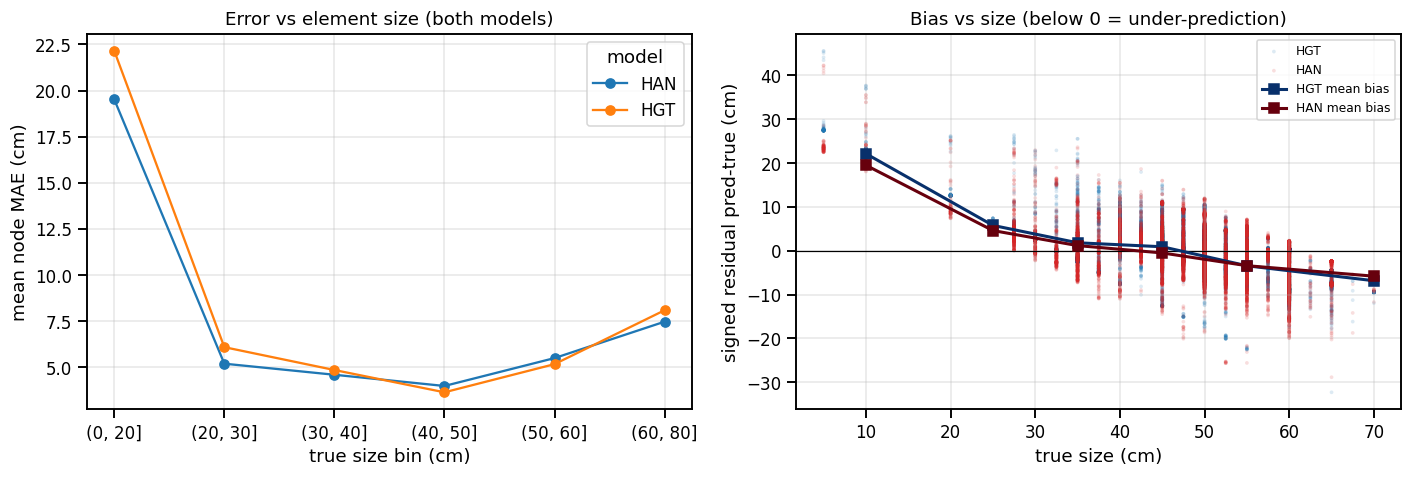

In [10]:
# --- Cell 10: isolated vs connected + error-vs-size structure (bias/heteroscedasticity) ---
# use the deployment external test per-node (real held-out). combine both models.
def enrich(df, model):
    d=df.copy(); d["model"]=model.upper()
    d["true_size"]=(d.true_b+d.true_h)/2
    d["resid"]=((d.pred_b-d.true_b)+(d.pred_h-d.true_h))/2
    return d
te = pd.concat([enrich(load_csv(m,"test_pernode_errors.csv"), m) for m in MODELS], ignore_index=True)

print("External test — MAE by isolation status & type (cm):")
print(te.groupby(["model","node_type","was_isolated"])["node_mae"].agg(["mean","size"]).to_string())

fig, ax = plt.subplots(1,2, figsize=(13,4.5))
# error vs true size, binned
te["size_bin"]=pd.cut(te.true_size, bins=[0,20,30,40,50,60,80,120])
g=te.groupby(["model","size_bin"])["node_mae"].mean().unstack(0)
g.plot(marker="o", ax=ax[0]); ax[0].set_ylabel("mean node MAE (cm)"); ax[0].set_xlabel("true size bin (cm)")
ax[0].set_title("Error vs element size (both models)"); ax[0].grid(alpha=.3)
# signed residual vs size -> systematic bias?
for m,c in [("HGT","#1f77b4"),("HAN","#d62728")]:
    s=te[te.model==m]; ax[1].scatter(s.true_size, s.resid, s=6, alpha=.15, color=c, label=m, edgecolors="none")
ax[1].axhline(0,color="k",lw=.8)
# binned mean bias line
for m,c in [("HGT","#08306b"),("HAN","#67000d")]:
    s=te[te.model==m].groupby("size_bin")["resid"].mean()
    ax[1].plot([iv.mid for iv in s.index], s.values, color=c, lw=2, marker="s", label=f"{m} mean bias")
ax[1].set_xlabel("true size (cm)"); ax[1].set_ylabel("signed residual pred-true (cm)")
ax[1].set_title("Bias vs size (below 0 = under-prediction)"); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
fig.tight_layout(); fig.savefig(os.path.join(FIG,"error_vs_size.png"), bbox_inches="tight"); plt.show()

## 5. Verdict & saved artifacts

Pulls the analysis together: best model+combo, whether the difference is meaningful, and the data-quality flags to act on.

In [11]:
# --- Cell 11: verdict summary ---
summary = {}
# best internal + external
int_best = sweep.sort_values("weighted_MAE").iloc[0]
summary["internal_best"] = {"model":int_best["model"], "combo":f"{int_best['PE']}/{int_best['isolated']}",
                            "weighted_MAE":float(int_best["weighted_MAE"]),
                            "hit_rate":float(int_best["pct_within_tol"]), "R2":float(int_best["overall_R2"])}
if len(ext):
    ext_best_model = ext["weighted_MAE"].idxmin()
    summary["external_best"] = {"model":ext_best_model,
                                "weighted_MAE":float(ext.loc[ext_best_model,"weighted_MAE"]),
                                "gap_to_other_cm": float(abs(ext["weighted_MAE"].diff().dropna().iloc[0]))}
summary["data_quality"] = {
    "n_unique_nodes": int(len(lab)),
    "tiny_elements(<15cm)": int(lab["tiny"].sum()),
    "tiny_pct": round(100*lab["tiny"].mean(),2),
    "suspect_samples_both_fail": suspect.index.tolist(),
    "label_suspect_nodes(A)": int((susp.cause.str.startswith("A")).sum()),
    "underfit_nodes(B)": int((susp.cause.str.startswith("B")).sum()),
    "label_suspect_samples": susp[susp.cause.str.startswith("A")]["sample"].unique().tolist(),
}
with open(os.path.join(OUT,"analysis_summary.json"),"w") as f:
    json.dump(summary, f, indent=2, default=float)

print("="*70); print("VERDICT"); print("="*70)
ib=summary["internal_best"]
print(f"Best on INTERNAL split : {ib['model']} @ {ib['combo']}  "
      f"-> {ib['weighted_MAE']:.3f} cm | hit {ib['hit_rate']:.1f}% | R2 {ib['R2']:.3f}")
if "external_best" in summary:
    eb=summary["external_best"]
    print(f"Best on EXTERNAL test  : {eb['model']}  -> {eb['weighted_MAE']:.3f} cm "
          f"(gap to other model = {eb['gap_to_other_cm']:.3f} cm)")
print(f"\nDATA QUALITY:")
dq=summary["data_quality"]
print(f"  implausibly small elements (<15cm): {dq['tiny_elements(<15cm)']} ({dq['tiny_pct']}%)")
print(f"  data-suspect graphs (both models fail): {len(dq['suspect_samples_both_fail'])} -> {dq['suspect_samples_both_fail']}")
print(f"  (A) LABEL-SUSPECT nodes (fix the data): {dq['label_suspect_nodes(A)']} "
      f"in samples {dq['label_suspect_samples']}")
print(f"  (B) UNDERFIT nodes (model/feature limit): {dq['underfit_nodes(B)']}")
print(f"\nArtifacts written to {os.path.abspath(OUT)}:")
for f in sorted(os.listdir(OUT)):
    if os.path.isfile(os.path.join(OUT,f)): print("   ", f)
print("   figures/ ->", ", ".join(sorted(os.listdir(FIG))))
summary

VERDICT
Best on INTERNAL split : HAN @ topological/none  -> 5.512 cm | hit 63.9% | R2 0.552
Best on EXTERNAL test  : HGT  -> 4.930 cm (gap to other model = 0.107 cm)

DATA QUALITY:
  implausibly small elements (<15cm): 46 (0.56%)
  data-suspect graphs (both models fail): 4 -> ['sample_240', 'sample_151', 'sample_233', 'sample_189']
  (A) LABEL-SUSPECT nodes (fix the data): 46 in samples ['sample_39', 'sample_191', 'sample_192', 'sample_31', 'sample_6']
  (B) UNDERFIT nodes (model/feature limit): 1087

Artifacts written to /Users/sarayetel/Desktop/Research/Graph/RC-Element-Prediction-GNN/results/analysis:
    analysis_summary.json
    architecture_ab_by_combo.csv
    combined_external_test.csv
    combined_sweep.csv
    node_labels_flagged.csv
    sample_mae_both_models.csv
    suspect_nodes.csv
    suspect_samples.csv
   figures/ -> best_combo_headtohead.png, error_vs_size.png, external_test_headtohead.png, label_distribution.png, sample_error_agreement.png, sweep_heatmaps.png


{'internal_best': {'model': 'HAN',
  'combo': 'topological/none',
  'weighted_MAE': 5.512,
  'hit_rate': 63.9,
  'R2': 0.552},
 'external_best': {'model': 'HGT',
  'weighted_MAE': 4.93,
  'gap_to_other_cm': 0.1070000000000002},
 'data_quality': {'n_unique_nodes': 8281,
  'tiny_elements(<15cm)': 46,
  'tiny_pct': 0.56,
  'suspect_samples_both_fail': ['sample_240',
   'sample_151',
   'sample_233',
   'sample_189'],
  'label_suspect_nodes(A)': 46,
  'underfit_nodes(B)': 1087,
  'label_suspect_samples': ['sample_39',
   'sample_191',
   'sample_192',
   'sample_31',
   'sample_6']}}